In [1]:
# importing pandas
import pandas as pd


Next we need to read the train.csv data that we dropped here. With head() we are given the first 5 results.

In [2]:
df = pd.read_csv('train.csv', encoding='ISO-8859-1')
df.head()

,textID,text,selected_text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral,morning,0-20,Afghanistan,38928346,652860.0,60
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative,noon,21-30,Albania,2877797,27400.0,105
2,088c60f138,my boss is bullying me...,bullying me,negative,night,31-45,Algeria,43851044,2381740.0,18
3,9642c003ef,what interview! leave me alone,leave me alone,negative,morning,46-60,Andorra,77265,470.0,164
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative,noon,60-70,Angola,32866272,1246700.0,26


Next let's check if the data has null-values, which could cause problems later. We see that there is a couple: one in text-column and one on selected_text.

In [3]:
df.isnull().sum()

textID              0
text                1
selected_text       1
sentiment           0
Time of Tweet       0
Age of User         0
Country             0
Population -2020    0
Land Area (Km²)     0
Density (P/Km²)     0
dtype: int64

Let's remove those nulls.

In [4]:
# inplace means this will replace the values in the same data table,
# which means we don't need to save it to a new variable
df.dropna(inplace=True)

# let's check again if there a re nulls with the code snippet above.
# Results: Zero nulls.


With describe we can see some basic data, like a mean value of the columns.

This seems to display only the strictly numeric values (which excludes the age gap column): population, land area and density.

In [5]:
df.describe()

,Population -2020,Land Area (Km²),Density (P/Km²)
count,2.748000e+04,2.748000e+04,27480.000000
mean,4.018634e+07,6.621672e+05,357.699491
std,1.504972e+08,1.807457e+06,2013.786207
min,8.010000e+02,0.000000e+00,2.000000
25%,1.968001e+06,2.281000e+04,35.000000
50%,8.655535e+06,1.118900e+05,89.000000
75%,2.843594e+07,5.279700e+05,214.000000
max,1.439324e+09,1.637687e+07,26337.000000


# Training
I think I should choose the columns for  *text* and *sentiment* for this. I should train the model with the *text* and compare the results with *sentiment* to see if the training went well. This means that the results for each text should correspond with the sentiment.

I chose to split the data so that 75% is used for training and 25% for testing. If I understood correctly, the random_state is a random value that will make sure the split is reproducible while being random.

In [6]:
from sklearn.model_selection import train_test_split

# this seperates the columns from the original dataframe to seperate variables
text = df['text']
sentiment = df['sentiment']

text_train, text_test, sentiment_train, sentiment_test = train_test_split(text, sentiment, test_size=0.25, random_state=39)


Next we will actually train the model. This will vectorize and classify the data using packages from the sklearn import.

The Pipeline is an optional helper tool to run several steps in one coherent step.

The TfidfVectorizer does the vectorizing and the LinearSVC does the classification (linear)

Then we fit the data which basically is the training itself

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

text_classifier = Pipeline([
    ('vectorizing', TfidfVectorizer()),
    ('classification', LinearSVC())
])


text_classifier.fit(text_train, sentiment_train)



,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('vectorizing', ...), ('classification', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


# Testing the model
We test this model by using the testing part of the data (the 25%) and compare it to the results the model gives us.

In [8]:
from sklearn.metrics import classification_report

predictions = text_classifier.predict(text_test)

print(classification_report(sentiment_test, predictions))

              precision    recall  f1-score   support

    negative       0.70      0.63      0.66      1949
     neutral       0.64      0.70      0.67      2841
    positive       0.74      0.71      0.73      2080

    accuracy                           0.68      6870
   macro avg       0.69      0.68      0.69      6870
weighted avg       0.69      0.68      0.68      6870



The testing looks good. The support field seems quite equally distributed which means that there is the same amount of training data for all the values.

Precision is also quite ok with the average of 70%

 With these results we can build a confusion matrix, which basically shows how wrong/right the model was. We visualize the results with Matplotlib.

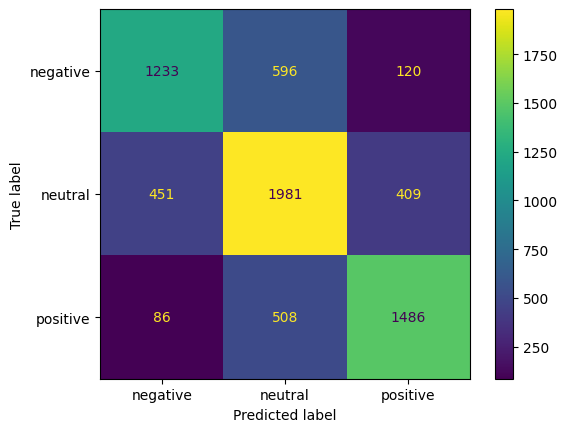

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

conf_matrix = confusion_matrix(sentiment_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels = text_classifier.classes_)

# visualizing the results
disp.plot()
plt.show()


I would say the results are okay. The yellow and green colors are in the correctly predicted spots. There are also wrong results and this seems to vizualize the 70% accuracy quite well. The totally wrong answers are the smallest group which is good.

# My own sentences
The negative results didn't come as easily as I thought, so I added an extra "extremely negative" group to test it more.

In [10]:
print("My positive sentences were predicted as: ",
      text_classifier.predict(["I feel great today."]),
      text_classifier.predict(["Finland won ice hockey."]), # this one was funny :)
      text_classifier.predict(["I am drinking my favourite drink."])
      )

print("My neutral sentences were predicted as: ",
      text_classifier.predict(["Hello world"]),
      text_classifier.predict(["I turn the light off at night."]),
      text_classifier.predict(["I am watching the news."])
      )

print("My negative sentences were predicted as: ",
      text_classifier.predict(["Sweden won ice hockey."]),
      text_classifier.predict(["I stepped in water with socks."]),
      text_classifier.predict(["I had 3 hours of sleep last night."])
      )

print("My extremely negative sentences were predicted as: ",
      text_classifier.predict(["I feel like shouting at everyone."]),
      text_classifier.predict(["I want to punch the wall."]),
      text_classifier.predict(["My aunt's dog dies today."])
      )

My positive sentences were predicted as:  ['positive'] ['negative'] ['positive']
My neutral sentences were predicted as:  ['neutral'] ['neutral'] ['neutral']
My negative sentences were predicted as:  ['neutral'] ['neutral'] ['neutral']
My extremely negative sentences were predicted as:  ['negative'] ['negative'] ['negative']
